In [1]:
# conda install -c conda-forge xarray


In [2]:
# conda install -c conda-forge matplotlib scipy pandas xarray xrft


In [3]:
# conda install -c conda-forge netcdf4 h5netcdf


In [4]:
# conda install -c conda-forge netcdf4 h5netcdf cftime dask


In [11]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import glob
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import xrft as xt

In [12]:
ds1 = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Edited_plots/merged_files/pH_ensemble_ssp585_merged_r1.nc')
ds2 = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Edited_plots/merged_files/pH_ensemble_ssp126_merged_r1.nc')
ds3 = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Edited_plots/merged_files/pH_ensemble_ssp245_merged_r1.nc')


In [13]:

ds1 = 10**(-1*ds1)
ds2 = 10**(-1*ds2)
ds3 = 10**(-1*ds3)


In [17]:
# ds3.to_netcdf(
#     '[H+]_ensemble_ssp245_merged_r1.nc'
# )

In [9]:
lat_range = slice(-30, 30)
lon_range = slice(30, 120)
month_hist  = ds2.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014'))#.groupby('time.month').mean()
month_FF_126  = ds2.sel(lat=lat_range, lon=lon_range, time=slice('2071', '2100'))#.groupby('time.month').mean()
month_FF_585  = ds1.sel(lat=lat_range, lon=lon_range, time=slice('2071', '2100'))#.groupby('time.month').mean()
month_FF_245  = ds3.sel(lat=lat_range, lon=lon_range, time=slice('2071', '2100'))#.groupby('time.month').mean()



In [10]:
month_FF_126

<xarray.Dataset> Size: 16MB
Dimensions:   (time: 360, lat: 61, lon: 91)
Coordinates:
  * time      (time) object 3kB 2071-01-15 12:00:00 ... 2100-12-15 12:00:00
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon       (lon) float32 364B 30.12 31.12 32.12 33.12 ... 118.1 119.1 119.9
    lev       float64 8B ...
    DEPTH1_1  float32 4B ...
    TIME      datetime64[ns] 8B ...
    method    <U7 28B ...
    olevel    float32 4B ...
Data variables:
    ph        (time, lat, lon) float64 16MB nan nan nan ... nan nan nan

In [11]:
import numpy as np
import xarray as xr
from scipy.stats import linregress
# import xarrayutils as xt

def calculate_ToE(ds, var='ph', time_dim='month', k=3):
    """
    Calculate Time of Emergence (ToE) for pH data.
    """

    # ---- Ensure DataArray ----
    if isinstance(ds, xr.Dataset):
        ph = ds[var]
    else:
        ph = ds

    # ---- Trend ----
    def _slope(y):
        t = np.arange(len(y))
        mask = np.isfinite(y)
        if mask.sum() < 2:
            return np.nan
        return linregress(t[mask], y[mask]).slope * 12

    slope = xr.apply_ufunc(
        _slope,
        ph,
        input_core_dims=[[time_dim]],
        vectorize=True,
        output_dtypes=[float]
    )

    # ---- Noise (detrended std) ----
    valid_mask = ph.isel({time_dim: 0}).notnull()
    ph_filled = ph.fillna(0)

    detrended = xt.detrend(
        ph_filled,
        dim=time_dim,
        detrend_type='linear'
    )

    noise = detrended.where(valid_mask).std(dim=time_dim)

    # ---- ToE ----
    toe = k * noise / abs(slope)

    return toe


In [12]:
Toe_hist = calculate_ToE(
    month_hist,   # Dataset is OK now
    var='ph',
    time_dim='time',
    k=3
)

/home/athira/miniconda3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [13]:
Toe_hist#.plot(robust=True)

<xarray.DataArray 'ph' (lat: 61, lon: 91)> Size: 44kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(61, 91))
Coordinates:
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon       (lon) float32 364B 30.12 31.12 32.12 33.12 ... 118.1 119.1 119.9
    lev       float64 8B 500.0
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    method    <U7 28B 'nearest'
    olevel    float32 4B 0.5058

In [14]:
Toe_126 = calculate_ToE(
    month_FF_126,   # Dataset is OK now
    var='ph',
    time_dim='time',
    k=3
)

/home/athira/miniconda3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


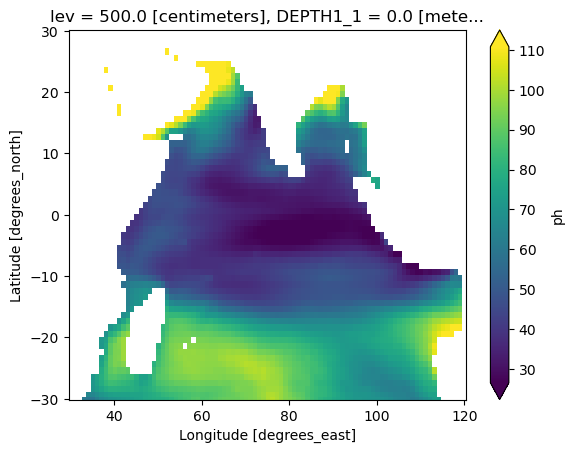

In [15]:
Toe_126.plot(robust=True)

In [16]:
Toe_total_period = calculate_ToE(
    ds2,   # Dataset is OK now
    var='ph',
    time_dim='time',
    k=3
)

/home/athira/miniconda3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


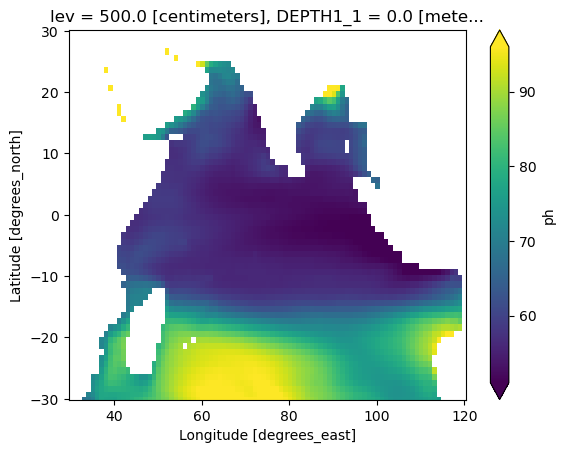

In [17]:
Toe_total_period.plot(robust=True)

In [18]:
Toe_585 = calculate_ToE(
    month_FF_585,   # Dataset is OK now
    var='ph',
    time_dim='time',
    k=3
)

/home/athira/miniconda3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


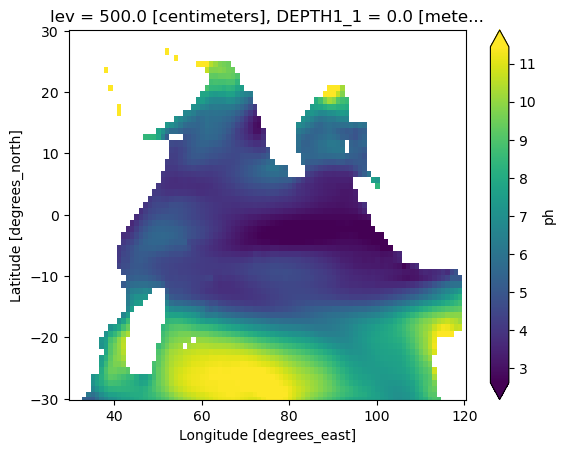

In [19]:
Toe_585.plot(robust=True)

In [20]:
Toe_245 = calculate_ToE(
    month_FF_245,   # Dataset is OK now
    var='ph',
    time_dim='time',
    k=3
)

/home/athira/miniconda3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


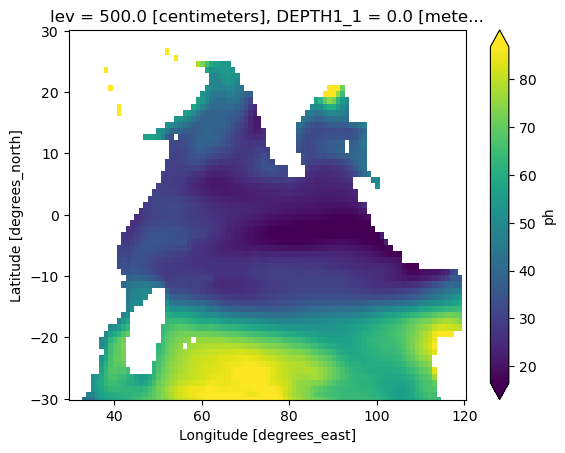

In [21]:
Toe_245.plot(robust=True)

In [22]:

# def calculate_slope(data_array):
#     slopes = np.apply_along_axis(lambda y: linregress(range(len(y)), y).slope*12, axis=0, arr=data_array)
#     return slopes

# def spatial_trend(data):
#     slope = xr.apply_ufunc(
#         calculate_slope,
#         data,
#         input_core_dims=[["month"]],  # Apply along 'time' dimension
#         vectorize=True
#     )
#     return slope

# def detrend_data(data, time_dim='month', fill_value=999):
#     valid_mask = data.isel({time_dim: 0}).notnull()
#     data_filled = data.fillna(fill_value)
#     detrended = xt.detrend(data_filled, dim=time_dim, detrend_type='linear').where(valid_mask)
#     # std = detrended.std(dim='TIME')
#     return detrended #std
   
# def ToE (data):
#     slope = spatial_trend(data)
#     std = detrend_data(data).std(dim='month')
#     ToE = 3*std/abs(slope)
#     return ToE


# Toe_anyperiod = ToE(data)
# ## modify the name TIME according to your data... 

# plot

In [22]:
# conda install -c conda-forge cartopy

In [23]:
# conda install -c conda-forge basemap


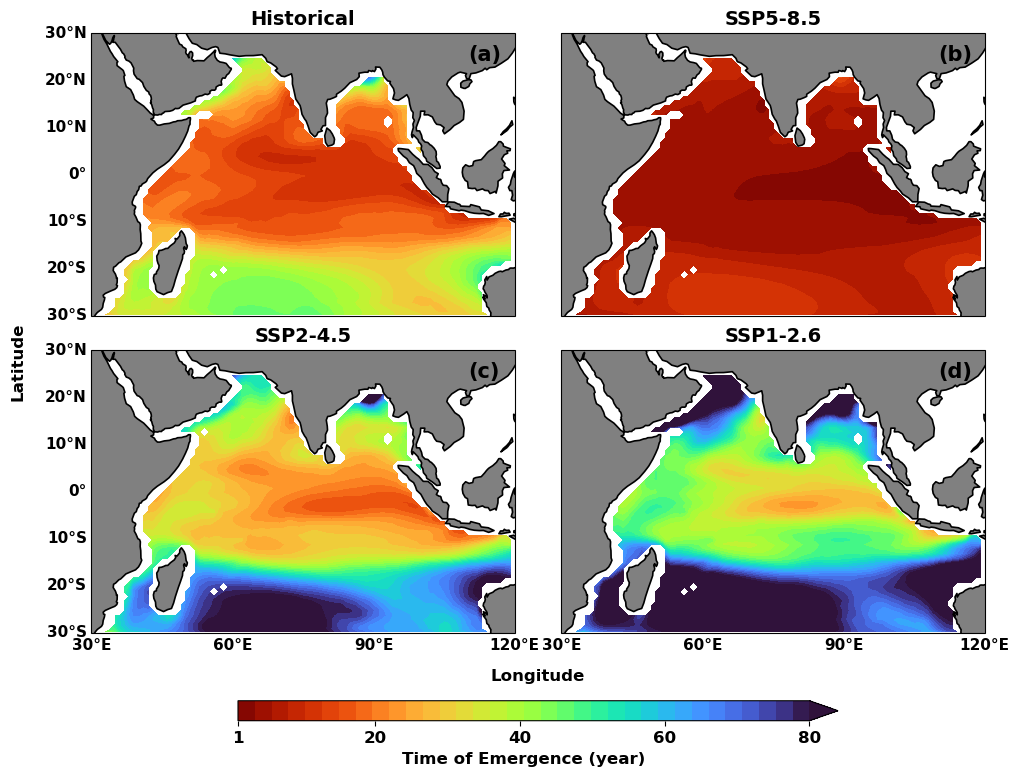

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.basemap import Basemap

plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13

# ---- Colorbar limits ----
vmin = 1
vmax = 80
levels = np.linspace(vmin, vmax, 35)

# ---- subplot labels ----
subplot_labels = ['(a)', '(b)', '(c)', '(d)']

# ---- Create figure and axes ----
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(12, 8),
    sharex=True,
    sharey=True,
    subplot_kw={'projection': ccrs.PlateCarree()}
)

plt.subplots_adjust(bottom=0.20, top=0.95, left=0.1, right=0.9,
                    wspace=-0.04, hspace=0.12)

# ---- Titles and data ----
titles = [
    "Historical",
    "SSP5-8.5",
    "SSP2-4.5",
    "SSP1-2.6"
]

data_list = [
    Toe_hist,
    Toe_585,
    Toe_245,
    Toe_126
]

# ---- Loop over subplots ----
for i, (ax, data, title) in enumerate(zip(axes.flat, data_list, titles)):

    row, col = divmod(i, 2)

    lon = data.lon
    lat = data.lat

    # ---- Contour plot ----
    im = ax.contourf(
        lon, lat, data,
        levels=levels,
        cmap='turbo_r',
        vmin=vmin,
        vmax=vmax,
        extend='max',
        transform=ccrs.PlateCarree()
    )

    # ---- Land mask & coastlines ----
    ax.add_feature(cfeature.LAND, facecolor='gray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=3)

    # ---- Basemap for grid labels ----
    m = Basemap(
        llcrnrlat=-30.1, urcrnrlat=30.1,
        llcrnrlon=30, urcrnrlon=120.1,
        resolution='c',
        ax=ax
    )

    if col == 0:
        m.drawparallels(
            range(-90, 120, 10),
            labels=[1,0,0,1],
            linewidth=0.001,
            dashes=[4,2],
            color='w',
            fontsize=11
        )

    if row == 1:
        m.drawmeridians(
            range(30,121,30),
            labels=[1,0,0,1],
            linewidth=0.001,
            color='w',
            fontsize=11
        )

    # ---- Subplot labels (a,b,c,d) ----
    ax.text(
        0.89, 0.96, subplot_labels[i],
        transform=ax.transAxes,
        fontsize=15,
        fontweight='bold',
        va='top',
        ha='left',
        color='black'
    )

    # ---- Title ----
    ax.set_title(title, fontsize=14, fontweight='bold')

    # ---- Tick labels ----
    ax.tick_params(axis='both', labelsize=13)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight('bold')

# ---- Common horizontal colorbar ----
cbar_ax = fig.add_axes([0.25, 0.09, 0.50, 0.025])

cbar = fig.colorbar(
    im,
    cax=cbar_ax,
    orientation='horizontal',
    extend='max'
)

# ---- Colorbar ticks every 30 ----
cbar.set_ticks([1, 20, 40, 60, 80])

cbar.set_label("Time of Emergence (year)", fontsize=12, fontweight='bold')

cbar.ax.tick_params(labelsize=12)
for tick in cbar.ax.get_xticklabels():
    tick.set_fontweight('bold')

# ---- Common axis labels ----
fig.text(0.50, 0.14, "Longitude",
         ha="center",
         fontsize=12,
         fontweight="bold")

fig.text(0.060, 0.54, "Latitude",
         va="center",
         rotation="vertical",
         fontsize=12,
         fontweight="bold")

# plt.savefig('ToE_cmip6_ens_r05.jpg', format='jpg', dpi=500)
plt.savefig('ToE_cmip6_review_f02.jpg', format='jpg', dpi=500)


plt.show()

In [ ]:
# l1_diff = np.arange(12, 17.5, 0.2)
# l2_diff = np.arange(17.5, 44, 27)
# l3_diff = np.arange(44, 56, 0.4)
# l4_diff = np.arange(56, 105, 55)
# l5_diff = np.arange(105, 135.5, 1)


# l6_diff = np.concatenate((l1_diff, l2_diff, l3_diff, l4_diff, l5_diff))
# norm_diff = colors.BoundaryNorm(l6_diff, ncolors=256)

#  m.contourf(lon, lat, ph_data, levels = l6_diff, norm = norm_diff, cmap=cmap1, zorder=10, extend='both')

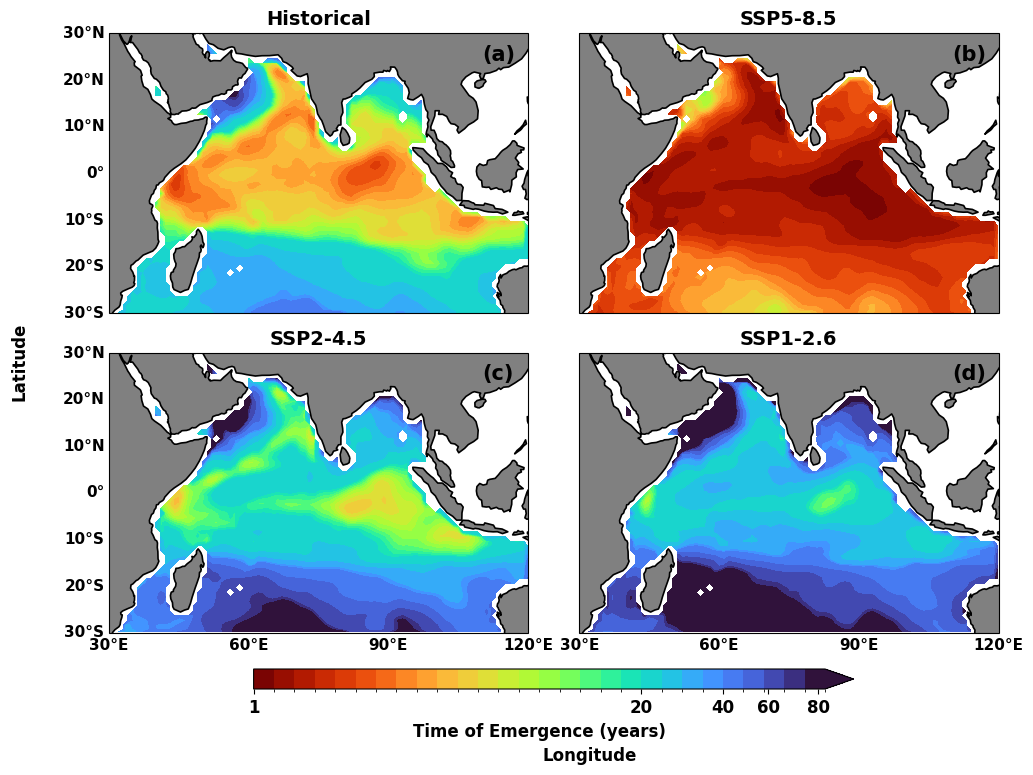

In [65]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.basemap import Basemap
import matplotlib.colors as colors

plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13

# ---- Colorbar limits ----
# vmin = 1
# vmax = 80
# levels = np.linspace(vmin, vmax, 38)

# ---- subplot labels ----
subplot_labels = ['(a)', '(b)', '(c)', '(d)']




l1_diff = np.arange(1, 20, 1)
l2_diff = np.arange(20, 40, 6)
l3_diff = np.arange(40, 70, 9)
l4_diff = np.arange(70, 100, 15)

l5_diff = np.concatenate((l1_diff, l2_diff, l3_diff, l4_diff))
norm_diff = colors.BoundaryNorm(l5_diff, ncolors=256)

# ---- Create figure and axes ----
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(12, 8),
    sharex=True,
    sharey=True,
    subplot_kw={'projection': ccrs.PlateCarree()}
)

plt.subplots_adjust(bottom=0.20, top=0.95, left=0.1, right=0.9,
                    wspace=-0.04, hspace=0.14)

# ---- Titles and data ----
titles = [
    "Historical",
    "SSP5-8.5",
    "SSP2-4.5",
    "SSP1-2.6"
]

data_list = [
    Toe_hist,
    Toe_585,
    Toe_245,
    Toe_126
]

# ---- Loop over subplots ----
for i, (ax, data, title) in enumerate(zip(axes.flat, data_list, titles)):

    row, col = divmod(i, 2)

    lon = data.lon
    lat = data.lat

    # ---- Contour plot ----
    im = ax.contourf(
        lon, lat, data,
        levels = l5_diff, 
        norm = norm_diff,
        cmap='turbo_r',
        extend='max',
        transform=ccrs.PlateCarree()
    )

    # ---- Land mask & coastlines ----
    ax.add_feature(cfeature.LAND, facecolor='gray', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=3)

    # ---- Basemap for grid labels ----
    m = Basemap(
        llcrnrlat=-30.1, urcrnrlat=30.1,
        llcrnrlon=30, urcrnrlon=120.1,
        resolution='c',
        ax=ax
    )

    if col == 0:
        m.drawparallels(
            range(-90, 120, 10),
            labels=[1,0,0,1],
            linewidth=0.001,
            dashes=[4,2],
            color='w',
            fontsize=11
        )

    if row == 1:
        m.drawmeridians(
            range(30,121,30),
            labels=[1,0,0,1],
            linewidth=0.001,
            color='w',
            fontsize=11
        )

    # ---- Subplot labels (a,b,c,d) ----
    ax.text(
        0.89, 0.96, subplot_labels[i],
        transform=ax.transAxes,
        fontsize=15,
        fontweight='bold',
        va='top',
        ha='left',
        color='black'
    )

    # ---- Title ----
    ax.set_title(title, fontsize=14, fontweight='bold')

    # ---- Tick labels ----
    ax.tick_params(axis='both', labelsize=13)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight('bold')

# ---- Common horizontal colorbar ----
cbar_ax = fig.add_axes([0.25, 0.13, 0.50, 0.025])

cbar = fig.colorbar(
    im,
    cax=cbar_ax,
    orientation='horizontal',
    extend='max'
)

# ---- Colorbar ticks every 30 ----
cbar.set_ticks([1, 20, 40, 60, 80])

cbar.set_label("Time of Emergence (years)", fontsize=12, fontweight='bold')

cbar.ax.tick_params(labelsize=12)
for tick in cbar.ax.get_xticklabels():
    tick.set_fontweight('bold')

# ---- Common axis labels ----
fig.text(0.53, 0.04, "Longitude",
         ha="center",
         fontsize=12,
         fontweight="bold")

fig.text(0.047, 0.54, "Latitude",
         va="center",
         rotation="vertical",
         fontsize=12,
         fontweight="bold")

# plt.savefig('ToE_bc_r05_boundarynorm.jpg', format='jpg', dpi=500)

plt.show()